**===Part Fatin===**

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
df.head()

Saving Teen_Mental_Health_Dataset.csv to Teen_Mental_Health_Dataset.csv


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


Check data

In [3]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.isnull().sum())

(1200, 13)
Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level 

Encode categorical variables

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['gender', 'platform_usage', 'social_interaction_level']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

Create target variable

In [5]:
# Create usage_habit_label

df['usage_habit_label'] = np.where(
    (df['daily_social_media_hours'] > df['daily_social_media_hours'].median()) &
    (df['addiction_level'] > df['addiction_level'].median()),
    1,  # Unhealthy
    0   # Healthy
)

df['usage_habit_label'].value_counts()

,count
usage_habit_label,
0,953
1,247


Check distribution

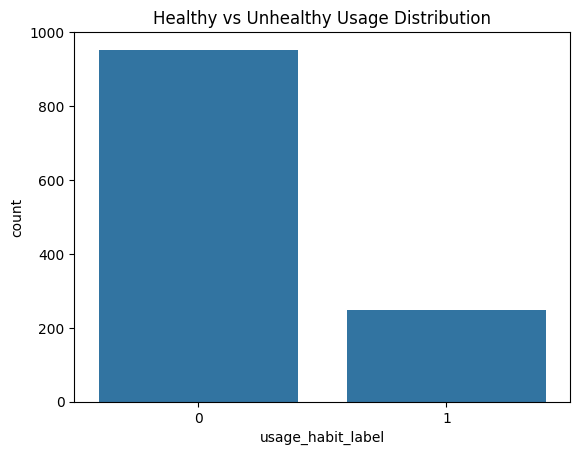

In [6]:
sns.countplot(x='usage_habit_label', data=df)
plt.title("Healthy vs Unhealthy Usage Distribution")
plt.show()

Define features (x) and target (y)

In [7]:
X = df.drop('usage_habit_label', axis=1)
y = df['usage_habit_label']

Train-test split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Train random forest model

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Predictions

In [10]:
y_pred = rf_model.predict(X_test)

Evaluation

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       191
           1       1.00      1.00      1.00        49

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



Confusion matrix

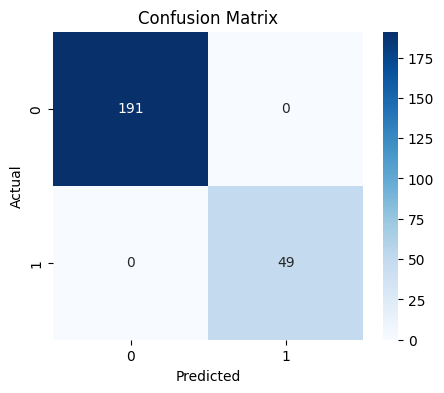

In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Feature importance

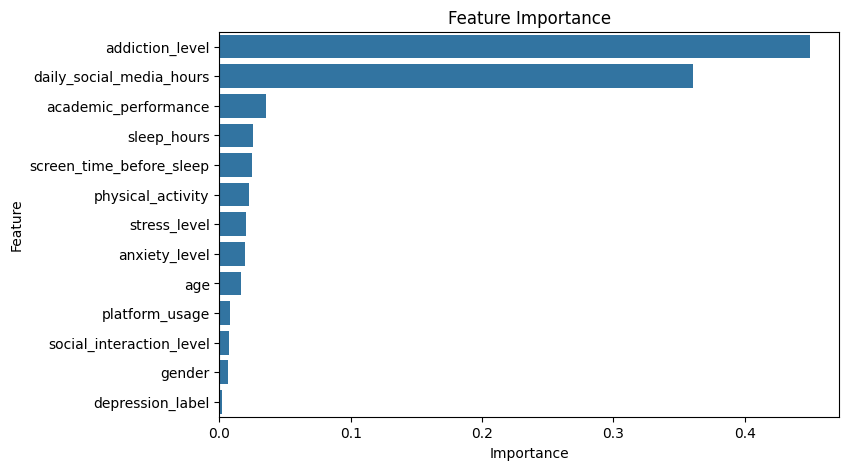

In [13]:
importances = rf_model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Feature Importance")
plt.show()

**===Part basyirah===**

Display Summary Statistics

In [14]:
df.describe()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,usage_habit_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,0.512500,4.536667,1.005833,6.449417,1.740333,2.990383,1.014500,1.039167,5.445833,5.636667,5.565000,0.025833,0.205833
std,2.021947,0.500052,2.029599,0.811181,1.442677,0.716660,0.576758,0.582185,0.808194,2.903290,2.859453,2.830627,0.158704,0.404478
min,13.000000,0.000000,1.000000,0.000000,4.000000,0.500000,2.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,14.000000,0.000000,2.800000,0.000000,5.200000,1.100000,2.500000,0.500000,0.000000,3.000000,3.000000,3.000000,0.000000,0.000000
50%,16.000000,1.000000,4.500000,1.000000,6.500000,1.800000,2.990000,1.000000,1.000000,5.000000,6.000000,6.000000,0.000000,0.000000
75%,18.000000,1.000000,6.300000,2.000000,7.600000,2.400000,3.480000,1.500000,2.000000,8.000000,8.000000,8.000000,0.000000,0.000000
max,19.000000,1.000000,8.000000,2.000000,9.000000,3.000000,4.000000,2.000000,2.000000,10.000000,10.000000,10.000000,1.000000,1.000000


Visualize Gender Distribution

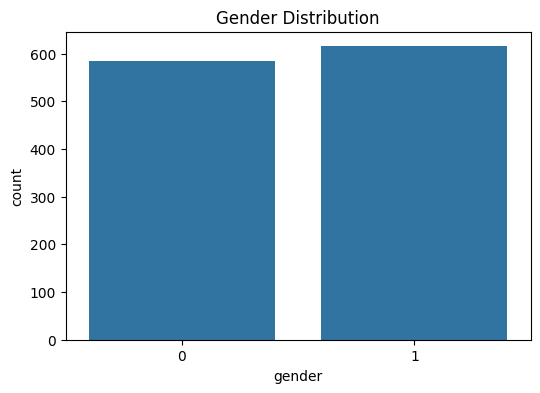

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)
plt.title('Gender Distribution')
plt.show()

Visualize Daily Social Media Usage

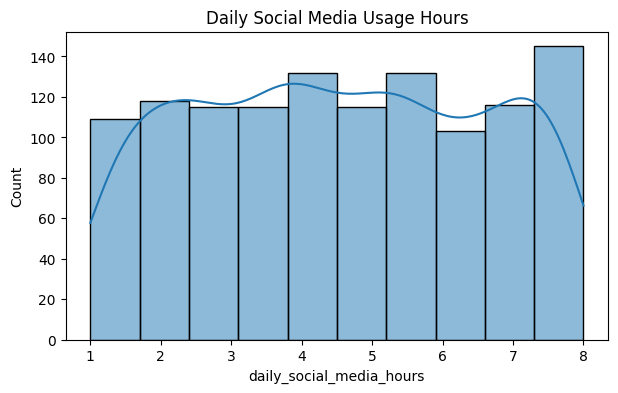

In [16]:
plt.figure(figsize=(7,4))
sns.histplot(df['daily_social_media_hours'], bins=10, kde=True)
plt.title('Daily Social Media Usage Hours')
plt.show()

Visualize Stress Level Distribution

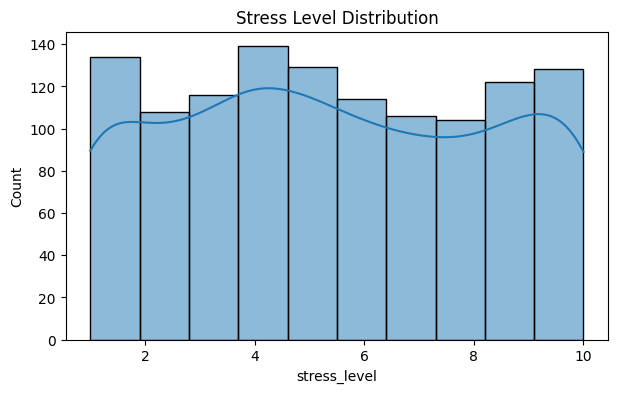

In [17]:
plt.figure(figsize=(7,4))
sns.histplot(df['stress_level'], bins=10, kde=True)
plt.title('Stress Level Distribution')
plt.show()

Visualize Depression Label Distribution

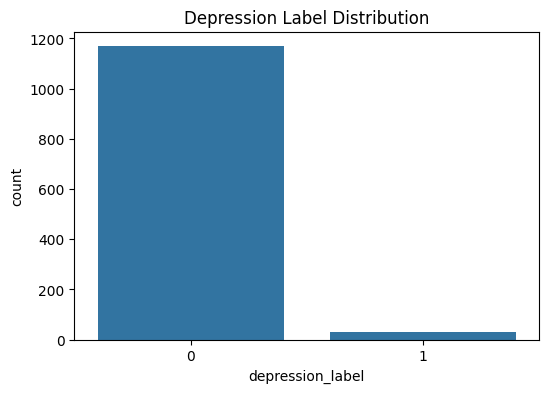

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x='depression_label', data=df)
plt.title('Depression Label Distribution')
plt.show()

Analyze Anxiety Level vs Depression Label

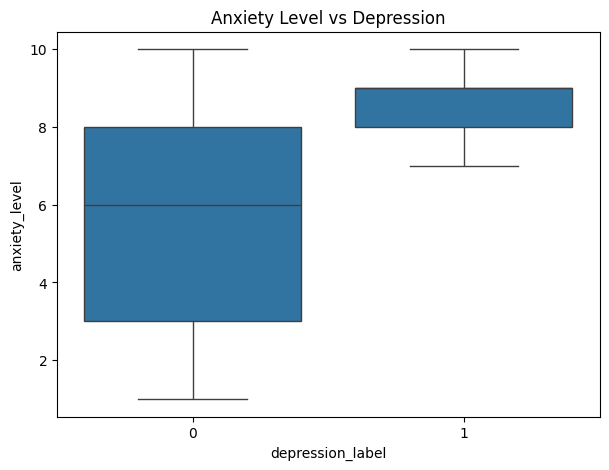

In [19]:
plt.figure(figsize=(7,5))
sns.boxplot(x='depression_label', y='anxiety_level', data=df)
plt.title('Anxiety Level vs Depression')
plt.show()

Generate Correlation Heatmap

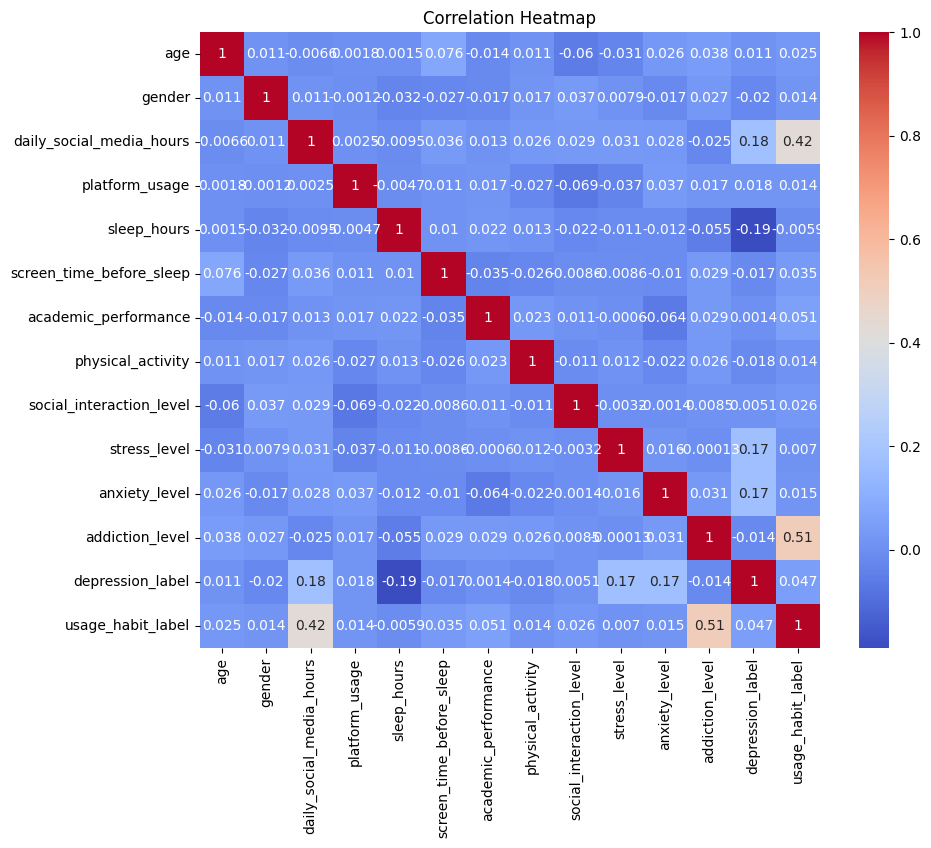

In [20]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

===PART NERA ====

In [22]:
print(df.columns.tolist())

['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label', 'usage_habit_label']


In [23]:
# Change your splitting cell to look exactly like this:
X = df.drop(columns=['usage_habit_label', 'depression_label']) # Drop both labels from features
y = df['usage_habit_label']                                    # This is your target variable

======